# Parameter Estimation for State-Space Models

This notebook covers parameter estimation for state-space models using two complementary approaches:

- **Maximum Likelihood Estimation (MLE)** via the Kalman filter log-likelihood (exact, only for linear Gaussian models)
- **Particle Marginal Metropolis-Hastings (PMMH)** using the particle filter log-likelihood as an unbiased estimator of the marginal likelihood (applicable to any SSM)

Sections:
1. MLE for `SimpleLinearGaussianSSM` — closed-form Kalman log-likelihood + numerical optimization
2. PMMH for `SimpleLinearGaussianSSM` — Bayesian posterior inference
3. Compare PMMH and BlockedPMMH
4. Effect of `N_particles` on PMMH — variance, bias, and the `alpha·sigma` identification issue
    - discuss how to set threshold on log-likelihood variance to choose `N_particles`, also could reference `testing_estimation.ipynb` results
5. Effect of observation noise `τ` on parameter recoverability
6. Model misspecification — fitting a Gaussian SSM to t-distributed or ARMA data
7. Compare (naive and blocked) PMMH, Kim filter MLE, (naive and blocked) RBPF PMMH for regime-switching models

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from models.linear_gaussian import SimpleLinearGaussianSSM, LinearGaussianSSM
from models.linear_t import LinearTSSM
from models.linear_ARMA import LinearARMASSM
from estimation.particle_filter import ParticleFilter
from estimation.kalman_filter import KalmanFilter
from estimation.resampling_methods import SystematicResampling
from estimation.pmmh import PMMH, BlockPMMH
from estimation.mle_estimator import MLEEstimator
from utils import rmse

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

---
## 1. MLE via Kalman filter log-likelihood

For `SimpleLinearGaussianSSM` the marginal log-likelihood $\log p(y_{1:T} \mid \theta)$ is analytically
tractable via the Kalman filter recursion (implemented in `model.log_likelihood(y)`).
We can therefore find the MLE by maximizing over the parameter vector $\theta = (\phi, \alpha, \sigma, \tau)$
using `scipy.optimize.minimize`.

Parameters are transformed to an unconstrained space via `model.unconstrain_params` (e.g. `tanh` for
$\phi$, `log` for positive scale parameters) before optimization, then mapped back with
`model.constrain_params`.

We compare MLE estimates against:
- the **true generating parameters**
- the **profile log-likelihood** surface to visualize identifiability

T=300  true log p(y|θ*)=-411.06
True params: {'phi': 0.9, 'alpha': 1.0, 'sigma': 0.5, 'tau': 1.0}


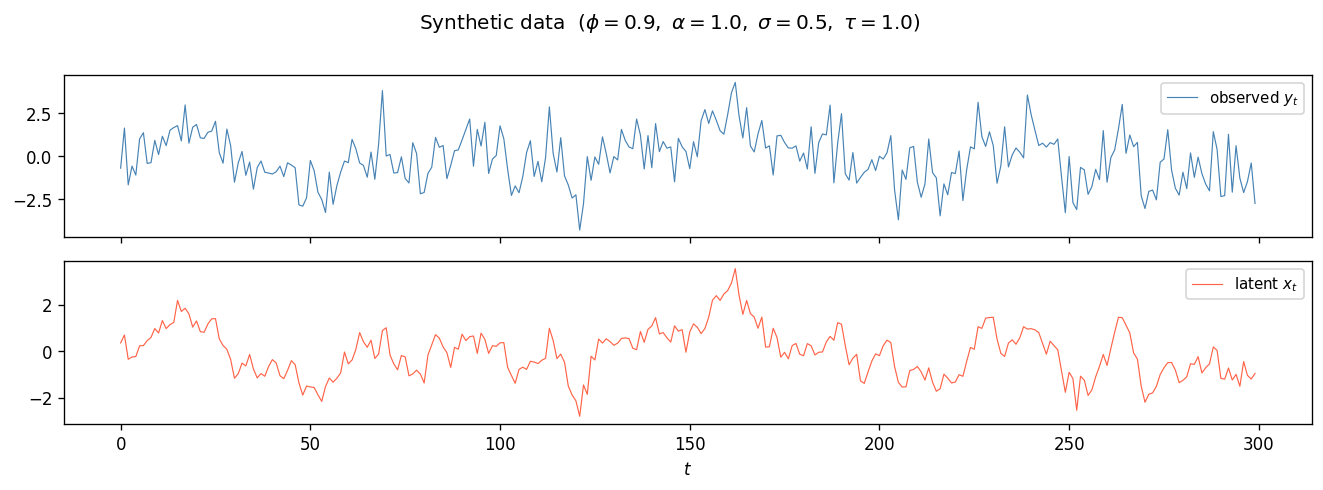

In [7]:
# ── true parameters and synthetic dataset ─────────────────────────────────────
TRUE_PARAMS = dict(phi=0.9, alpha=1.0, sigma=0.5, tau=1.0)
T    = 300
SEED = 42

model = SimpleLinearGaussianSSM(**TRUE_PARAMS, seed=SEED)
states_raw, obs_raw, true_loglik = model.generate_data(T)
states = states_raw.ravel()   # (T,)
obs    = obs_raw.ravel()      # (T,)

print(f"T={T}  true log p(y|θ*)={true_loglik[0]:.2f}")
print(f"True params: {TRUE_PARAMS}")

fig, axes = plt.subplots(2, 1, figsize=(11, 4), sharex=True)
axes[0].plot(obs,    lw=0.7, color='steelblue', label='observed $y_t$')
axes[1].plot(states, lw=0.7, color='tomato',    label='latent $x_t$')
for ax in axes:
    ax.legend(loc='upper right', fontsize=9)
axes[1].set_xlabel('$t$')
fig.suptitle(
    r'Synthetic data  ($\phi=0.9,\ \alpha=1.0,\ \sigma=0.5,\ \tau=1.0$)',
    y=1.01,
)
plt.tight_layout()
plt.show()

In [8]:
# ── MLE via MLEEstimator ──────────────────────────────────────────────────────
# MLEEstimator maximizes model.log_likelihood(data) using scipy.optimize.minimize
# (L-BFGS-B by default).  Optimization happens in the *unconstrained* parameter
# space (atanh φ, α, log σ, log τ) so no box constraints are needed; results
# are mapped back to the constrained space in MLEResult.constrained_params.
#
# n_restarts=3: the best optimum over 3 random restarts is returned, which helps
# avoid local optima that can appear with highly persistent AR processes.

mle = MLEEstimator(model, obs, n_restarts=3, restart_std=0.3, seed=0)
result = mle.fit()
mle.compute_std_errors()   # numerical Hessian + delta method → fills result.std_errors

print(result.summary())

MLEResult  loglik=-495.5197  converged  n_evals=65
  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

  Parameter             Estimate     Std error
  --------------------------------------------
  phi                   0.852314      0.053785
  alpha                 0.942855      0.000000
  sigma                 0.619063      0.000000
  tau                   0.987916      0.073832


Param         True         MLE          SE   |bias|/SE
────────────────────────────────────────────────────
phi         0.9000      0.8523      0.0538        0.89
alpha       1.0000      0.9429           —           —
sigma       0.5000      0.6191           —           —
tau         1.0000      0.9879      0.0738        0.16


<>:31: SyntaxWarning: invalid escape sequence '\h'
<>:31: SyntaxWarning: invalid escape sequence '\h'
/var/folders/6t/j_420_511zsftkrvyzgx57l80000gn/T/ipykernel_52020/1066983048.py:31: SyntaxWarning: invalid escape sequence '\h'
  label='KF filtered $\hat{x}_t$ (MLE params)', zorder=3)


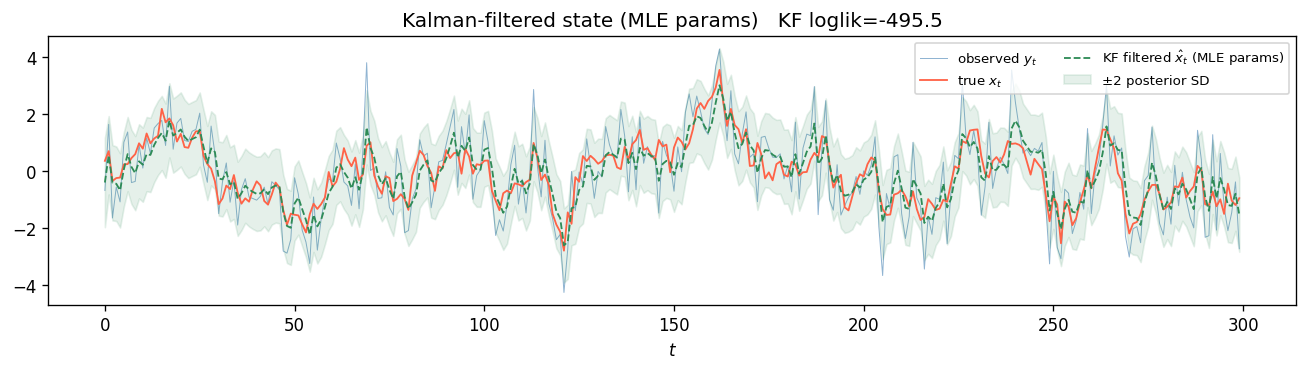

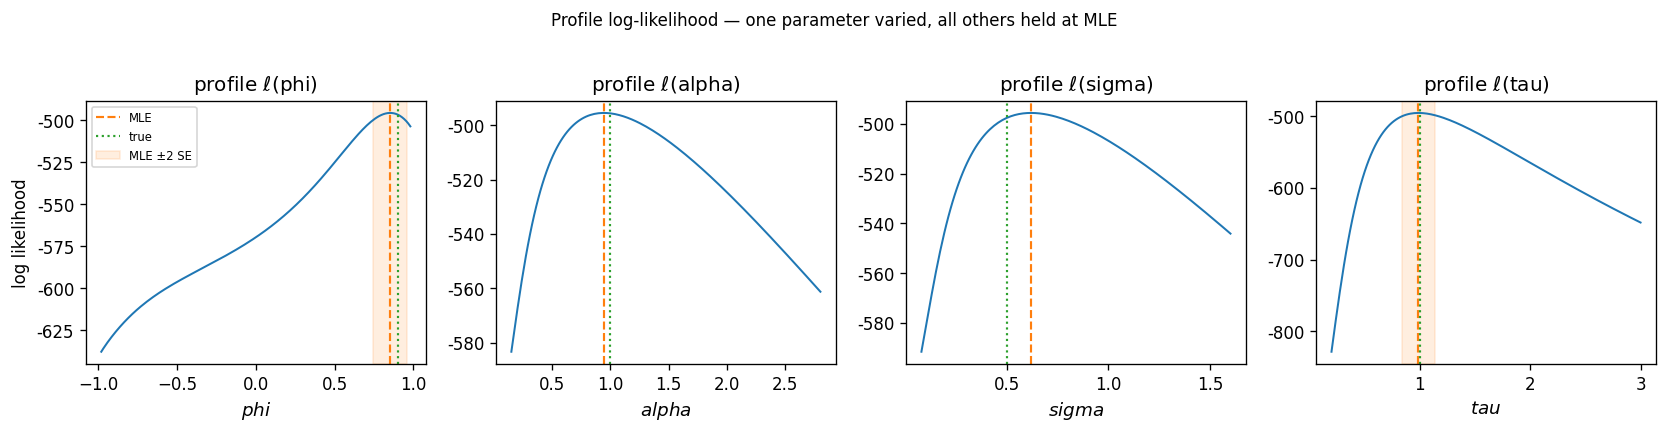

In [9]:
# ── comparison table and plots ────────────────────────────────────────────────
names   = result.param_names                  # ['phi', 'alpha', 'sigma', 'tau']
mle_est = list(result.constrained_params)
ses     = list(result.std_errors) if result.std_errors is not None else [None] * 4
trues   = [TRUE_PARAMS[p] for p in names]

print(f"{'Param':<8}  {'True':>8}  {'MLE':>10}  {'SE':>10}  {'|bias|/SE':>10}")
print("─" * 52)
for name, tv, mv, se in zip(names, trues, mle_est, ses):
    if se is not None and se > 0:
        print(f"{name:<8}  {tv:>8.4f}  {mv:>10.4f}  {se:>10.4f}  {abs(mv-tv)/se:>10.2f}")
    else:
        print(f"{name:<8}  {tv:>8.4f}  {mv:>10.4f}  {'—':>10}  {'—':>10}")

# ── Kalman filter with MLE params → filtered state ────────────────────────────
phi_m, alpha_m, sigma_m, tau_m = mle_est
lg_mle = LinearGaussianSSM(
    a=np.array([[phi_m]]),
    c=np.array([[alpha_m]]),
    q=np.array([[sigma_m**2]]),
    r=np.array([[tau_m**2]]),
)
kf_mle = KalmanFilter(lg_mle, obs)
filt_means, filt_covs, kf_loglik = kf_mle.run_filter()
filt_std = np.sqrt(filt_covs[:, 0, 0])

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(obs,    lw=0.6, color='steelblue', alpha=0.6, label='observed $y_t$', zorder=1)
ax.plot(states, lw=1.1, color='tomato',    label='true $x_t$',                zorder=2)
ax.plot(filt_means[:, 0], lw=1.1, color='seagreen', ls='--',
        label='KF filtered $\hat{x}_t$ (MLE params)', zorder=3)
ax.fill_between(range(T),
                filt_means[:, 0] - 2 * filt_std,
                filt_means[:, 0] + 2 * filt_std,
                color='seagreen', alpha=0.12, label='±2 posterior SD')
ax.set_xlabel('$t$')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.set_title(f'Kalman-filtered state (MLE params)   KF loglik={kf_loglik:.1f}')
plt.tight_layout()
plt.show()

# ── profile log-likelihoods (1-D slices through MLE) ─────────────────────────
grids = {
    'phi':   np.linspace(-0.98, 0.98, 150),
    'alpha': np.linspace(0.15, 2.80, 150),
    'sigma': np.linspace(0.08, 1.60, 150),
    'tau':   np.linspace(0.20, 3.00, 150),
}
mle_dict = dict(zip(names, mle_est))

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, name in zip(axes, names):
    lls = []
    for v in grids[name]:
        kwargs = {**mle_dict, name: v}
        try:
            m_tmp = SimpleLinearGaussianSSM(**kwargs)
            lls.append(m_tmp.log_likelihood(obs))
        except (ValueError, FloatingPointError):
            lls.append(np.nan)
    lls = np.array(lls)

    ax.plot(grids[name], lls, lw=1.2, color='C0')
    ax.axvline(mle_dict[name],    color='C1', ls='--', lw=1.3, label='MLE')
    ax.axvline(TRUE_PARAMS[name], color='C2', ls=':',  lw=1.3, label='true')

    # shade ±2 SE band around MLE
    idx = names.index(name)
    se  = ses[idx]
    if se is not None and se > 0:
        ax.axvspan(mle_dict[name] - 2*se, mle_dict[name] + 2*se,
                   alpha=0.13, color='C1', label='MLE ±2 SE')

    ax.set_xlabel(f'${name}$', fontsize=11)
    ax.set_title(f'profile $\\ell$({name})')
    if name == names[0]:
        ax.set_ylabel('log likelihood')
        ax.legend(fontsize=7)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

plt.suptitle('Profile log-likelihood — one parameter varied, all others held at MLE',
             y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

# Note: alpha and sigma profiles may look similarly shaped because the data
# primarily identifies the product α·σ (signal amplitude) — explored in Section 3.

---
## 2. PMMH parameter estimation

Particle Marginal Metropolis-Hastings replaces the intractable marginal likelihood
$p(y_{1:T} \mid \theta)$ with the particle filter's unbiased estimator $\hat{p}_N(y_{1:T} \mid \theta)$.
The resulting chain targets the exact posterior $p(\theta \mid y_{1:T})$ for any fixed $N$.

Setup:
- **Prior**: independent priors on each parameter (specified via `log_prior` in `PMMH`)
- **Proposal**: Gaussian random walk in the unconstrained space
- **Likelihood**: PF log-likelihood from `ParticleFilter.run_filter()`
- Parameters are constrained/unconstrained via `model.constrain_params` / `model.unconstrain_params`

We use the same synthetic dataset from Section 1 to allow direct comparison between MLE and PMMH estimates.

In [ ]:
# Define prior, initialize PMMH, set proposal scale
# implement

In [ ]:
# Run PMMH chain (e.g. 2000 iterations, discard first 500 as burn-in)
# implement

In [ ]:
# Diagnostics: trace plots, acceptance rate, effective sample size
# implement

In [ ]:
# Posterior marginal histograms for each parameter
# Overlay MLE point estimate and true parameter value
# implement

---
## 3. Block PMMH — updating parameters in independent groups

Standard PMMH proposes a joint update to all $d$ parameters simultaneously.
With $d=4$ and posterior correlation between $\alpha$ and $\sigma$ (the identification ridge),
a large joint step is often rejected, slowing mixing.

**Block PMMH** (`BlockPMMH`) partitions $\theta$ into groups and cycles through them each
iteration, accepting or rejecting each block independently:
- **Dynamics block** $(\phi, \sigma)$ — indices 0 and 2 in the unconstrained vector
- **Observation block** $(\alpha, \tau)$ — indices 1 and 3

Per-block proposals allow each block's effective step size to remain well-tuned even as
the other block moves.  We run both samplers on the **same dataset as Section 1** and compare:
- Overall acceptance rates
- Trace plots and posterior ESS
- Posterior marginals overlaid against the KF MLE

In [10]:
# ── setup: naive PMMH and Block PMMH on the same dataset ─────────────────────
# Uses dataset, model, and MLE result from Section 1.
# Block structure: dynamics (phi=0, sigma=2) and observation (alpha=1, tau=3)
# in the unconstrained vector order [phi, alpha, sigma, tau].
BLOCKS      = [[0, 2], [1, 3]]   # dynamics block, observation block
N_ITER_CMP  = 2000
N_PART_CMP  = 500
BURN_IN_CMP = 500

def log_prior(theta_unc):
    return -0.5 * np.sum(theta_unc ** 2)   # weak N(0,1) on each unconstrained dim

theta0 = model.unconstrain_params(result.constrained_params)
step   = np.array([0.10, 0.15, 0.10, 0.10])   # per-dim step sizes (unconstrained)

pf_n   = ParticleFilter(model, N_PART_CMP, obs, SystematicResampling(seed=1))
pmmh_n = PMMH(model, pf_n, n_iter=N_ITER_CMP,
              step_sizes=step, theta0=theta0, log_prior=log_prior, seed=10)

pf_b   = ParticleFilter(model, N_PART_CMP, obs, SystematicResampling(seed=2))
pmmh_b = BlockPMMH(model, pf_b, n_iter=N_ITER_CMP,
                   step_sizes=step, theta0=theta0, log_prior=log_prior,
                   blocks=BLOCKS, seed=20)

print(repr(pmmh_n))
print(repr(pmmh_b))

PMMH(model=SimpleLinearGaussianSSM(phi=0.8523144028728165, alpha=0.9428554774711047, sigma=0.6190626316371978, tau=0.9877185994324796), n_iter=2000, N_particles=500)
BlockPMMH(model=SimpleLinearGaussianSSM(phi=0.8523144028728165, alpha=0.9428554774711047, sigma=0.6190626316371978, tau=0.9877185994324796), n_iter=2000, N_particles=500, n_blocks=2)


In [ ]:
# ── run both chains ───────────────────────────────────────────────────────────
print("Running naive PMMH ...")
chain_n, ll_n, acc_n = pmmh_n.run()
print(f"  acceptance rate: {acc_n.mean():.3f}")

print("Running Block PMMH ...")
chain_b, ll_b, acc_b = pmmh_b.run()
print(f"  acceptance rate: {acc_b.mean():.3f}")

# Constrain samples and discard burn-in
def constrain_chain(ch, m):
    return np.array([m.constrain_params(row) for row in ch])

constrained_n = constrain_chain(chain_n[BURN_IN_CMP:], model)
constrained_b = constrain_chain(chain_b[BURN_IN_CMP:], model)

print(f"\n{'':8}  {'True':>8}  {'Naive mean':>12}  {'Block mean':>12}")
print("─" * 46)
for k, name in enumerate(model.params_dict.keys()):
    print(f"{name:<8}  {TRUE_PARAMS[name]:>8.4f}  "
          f"{constrained_n[:, k].mean():>12.4f}  "
          f"{constrained_b[:, k].mean():>12.4f}")

Running naive PMMH ...


In [ ]:
# ── trace plots and posterior comparison ──────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(13, 9))

for k, name in enumerate(model.params_dict.keys()):
    tv = TRUE_PARAMS[name]
    mv = mle_est[k]

    for col, (label, ch, color) in enumerate([
        ('Naive PMMH', constrained_n, 'steelblue'),
        ('Block PMMH', constrained_b, 'tomato'),
    ]):
        ax = axes[k, col]
        ax.plot(ch[:, k], lw=0.5, color=color, alpha=0.7)
        ax.axhline(tv, color='C2', ls=':', lw=1.2, label='true' if k == 0 else None)
        ax.axhline(mv, color='C1', ls='--', lw=1.2, label='MLE' if k == 0 else None)
        ax.set_ylabel(f'${name}$' if col == 0 else '')
        if k == 0:
            ax.set_title(label)
            ax.legend(fontsize=7)

    ax_m = axes[k, 2]
    lo = min(constrained_n[:, k].min(), constrained_b[:, k].min())
    hi = max(constrained_n[:, k].max(), constrained_b[:, k].max())
    bins = np.linspace(lo, hi, 40)
    for label, ch, color in [
        ('Naive PMMH', constrained_n, 'steelblue'),
        ('Block PMMH', constrained_b, 'tomato'),
    ]:
        ax_m.hist(ch[:, k], bins=bins, density=True, alpha=0.4, color=color, label=label)
    ax_m.axvline(tv, color='C2', ls=':', lw=1.5)
    ax_m.axvline(mv, color='C1', ls='--', lw=1.5)
    ax_m.set_xlabel(f'${name}$')
    if k == 0:
        ax_m.set_title('Posterior marginals')
        ax_m.legend(fontsize=7)

for col in range(2):
    axes[-1, col].set_xlabel('iteration (post burn-in)')
plt.suptitle(
    f'Naive PMMH (acc={acc_n.mean():.2f}) vs Block PMMH (acc={acc_b.mean():.2f})',
    y=1.01, fontsize=10,
)
plt.tight_layout()
plt.show()

---
## 4. Effect of N_particles on PMMH

The variance of the PF log-likelihood estimator scales as $O(1/N)$, which directly inflates the
posterior variance of the PMMH chain. We investigate:

- How posterior width and chain mixing depend on $N$
- How acceptance rate and ESS depend on $N$ (Question: How to tune resampling threshold?)
- How PMMH posterior means compare to the KF MLE baseline and true parameter values
- The **`alpha · sigma` identification issue**: because observations are
  $y_t = \alpha x_t + \epsilon_t$ and $x_t \sim \text{AR}(1)$ with noise $\sigma$, the product
  $\alpha \cdot \sigma$ is identified by the data but the individual factors may not be — a
  ridge in the log-likelihood surface. We visualize this and assess whether PMMH recovers
  the ridge or gets stuck.

In [ ]:
# Run PMMH at N in {50, 200, 500, 1000, 2000} on the same dataset
# Record: posterior mean/std per parameter, acceptance rate, chain ESS
# implement

In [ ]:
# Compare PMMH posterior means vs KF MLE vs true params, across N values
# implement

In [ ]:
# Visualize the alpha-sigma identification ridge:
#   plot the log-likelihood surface over a grid of (alpha, sigma) holding phi, tau fixed
#   overlay PMMH samples to show where the chain explores
# implement

---
## 5. Effect of observation noise on parameter estimation

Higher observation noise $\tau$ reduces the signal available for identifying the latent process
parameters $(\phi, \sigma)$. We sweep `tau_true` and examine:

- MLE estimation error (bias and variance across MC trials) for each parameter
- PMMH posterior width as a function of `tau_true`
- Whether the signal-to-noise ratio $\sigma / \tau$ is a better predictor of estimation quality
  than $\tau$ alone
- Limits of recoverability: at what $\tau$ does parameter estimation become unreliable?

In [ ]:
# For each tau in a grid, run MC trials of MLE and record bias/variance per parameter
# implement

In [ ]:
# For selected tau values, run PMMH and compare posterior widths
# implement

In [ ]:
# Plot: MLE bias and std vs tau_true (one subplot per parameter)
# Plot: PMMH posterior std vs tau_true
# implement

---
## 6. Model misspecification

We fit a `SimpleLinearGaussianSSM` (Gaussian noise, AR(1) latent) to data generated from:
- `LinearTSSM` — same AR(1) structure but with t-distributed process noise (heavy tails)
- `LinearARMASSM` — ARMA(1,3) latent process, richer autocorrelation structure

For each case we examine:
- MLE estimates under the misspecified model — which parameters absorb the specification error?
- PMMH posteriors under misspecification — does the posterior collapse or widen?
- Goodness-of-fit diagnostics: residual autocorrelation, filtered state RMSE, log-likelihood gap
  between the misspecified MLE and the correct model's true log-likelihood

In [ ]:
# Generate data from LinearTSSM and LinearARMASSM with matched AR parameters
# implement

In [ ]:
# Fit SimpleLinearGaussianSSM (MLE + PMMH) to LinearTSSM data
# Compare estimated params to true t-SSM params; show residual diagnostics
# implement

In [ ]:
# Fit SimpleLinearGaussianSSM (MLE + PMMH) to LinearARMASSM data
# Compare estimated params to true ARMA params; show residual diagnostics
# implement

In [ ]:
# Summary comparison:
#   log-likelihood gap (misspecified MLE vs correct model true loglik)
#   RMSE gap (misspecified filter vs correct filter)
# implement

---
## 7. Regime-switching model estimation

Markov-switching state-space models combine a discrete hidden Markov chain
$s_t \in \{0, \ldots, K-1\}$ with per-regime linear Gaussian dynamics.
The marginal likelihood over all $K^T$ possible regime sequences is intractable,
which rules out direct KF MLE.

We compare three approaches on a 2-regime model where the regimes differ only in
process noise variance (low-volatility vs high-volatility state):

| Method | Likelihood | Notes |
|--------|-----------|-------|
| Naive PMMH | PF log-lik (unbiased) | Joint proposal over all parameters |
| Block PMMH | PF log-lik (unbiased) | Transition matrix and per-regime params in separate blocks |
| Kim filter MLE | Approximate Kim log-lik | Deterministic, fast; bias from the collapse approximation |

True transition matrix: $P_{00}=0.95$, $P_{11}=0.90$ (persistent regimes).

In [ ]:
# ── 2-regime switching model: setup and data generation ───────────────────────
from models.regime_switching import RegimeSwitchingSSM
from estimation.kim_filter import KimFilter

# Regime 0: low-volatility  |  Regime 1: high-volatility
phi_r  = 0.8
A_list = [np.array([[phi_r]]), np.array([[phi_r]])]
C_list = [np.array([[1.0]]),   np.array([[1.0]])]
Q_list = [np.array([[0.25]]),  np.array([[1.00]])]   # σ² per regime
R_list = [np.array([[0.50]]),  np.array([[0.50]])]   # shared obs noise

P_true = np.array([[0.95, 0.05],
                   [0.10, 0.90]])

rs_model = RegimeSwitchingSSM(A_list, C_list, Q_list, R_list, P_true, seed=42)

# implement: generate data and plot time series with regime-coloured background
# states_rs, obs_rs, true_loglik_rs = rs_model.generate_data(T)

In [ ]:
# ── PMMH and Block PMMH for the regime-switching model ────────────────────────
# implement
# Note: RegimeSwitchingSSM needs constrain_params / unconstrain_params / update_params
# before this cell can run.
#
# Naive PMMH: joint proposal over all parameters (transition matrix + per-regime variances)
# Block PMMH: separate blocks for transition matrix rows and per-regime noise parameters
#
# pf_rs      = ParticleFilter(rs_model, N_PART, obs_rs, SystematicResampling(seed=5))
# pmmh_rs    = PMMH(rs_model, pf_rs, ...)
# pmmh_rs_b  = BlockPMMH(rs_model, pf_rs, ..., blocks=[...])

In [ ]:
# ── Kim filter MLE for the regime-switching model ─────────────────────────────
# implement
# kf_kim = KimFilter(rs_model, obs_rs)
# filtered_means_km, filtered_probs_km, loglik_km = kf_kim.run_filter()
#
# Maximize the Kim approximate log-likelihood with respect to the model parameters
# using MLEEstimator (requires RegimeSwitchingSSM.log_likelihood to call KimFilter
# internally, or a separate wrapper).  This is fast and deterministic, unlike PMMH.

In [ ]:
# ── compare all three methods ─────────────────────────────────────────────────
# implement
# Printed table: true params | PMMH posterior mean | Block PMMH posterior mean | Kim MLE
# Plot 1: filtered regime probabilities Pr(s_t=1 | y_{0:t}) from Kim filter vs
#         particle filter regime estimates
# Plot 2: filtered state means from Kim filter and particle filter vs true state

---
## Next steps

- **MLE for LinearARMASSM**: the ARMA latent structure admits an exact Kalman filter (via the state-space augmentation already implemented), enabling KF MLE for ARMA parameters as a baseline for the misspecification diagnostics in Section 6
- **RBPF PMMH**: Rao-Blackwellized particle filter analytically marginalizes the continuous state, reducing Monte Carlo variance and enabling more efficient PMMH for regime-switching models